In [3]:
# =========================
# 0. CARGAR LIBRERIAS
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# =========================
# 1. CARGAR DATOS
# =========================

df = pd.read_csv("eye_tracking.csv", sep=";")

In [5]:
# =========================
# 2. LIMPIEZA
# =========================

# reemplazar comas por puntos
df = df.replace(',', '.', regex=True)

# convertir columnas numéricas
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass

# limpiar nombres
df["Participant"] = df["Participant"].str.upper().str.strip()
df["AOI"] = df["AOI"].str.upper().str.strip()

In [6]:
# =========================
# 3. FILTRAR DESPEGUE
# =========================

df = df[df["TOI"].str.lower() == "despegue"]

# eliminar AOI irrelevantes (opcional)
#df = df[df["AOI"] != "MAP"]

In [7]:
# =========================
# 4. MÉTRICAS DERIVADAS
# =========================

# porcentaje de atención por piloto
df["Total_pilot"] = df.groupby("Participant")["Total_duration_of_fixations"].transform('sum')

df["Percentage"] = (
    df["Total_duration_of_fixations"] / df["Total_pilot"]
) * 100

In [8]:
df.style.set_table_styles(
    [dict(selector="th.col_heading", props=[("writing-mode", "vertical-rl"),
                                            ("transform", "rotate(180deg)"),
                                            ("text-align", "center")])
    ]
).format(precision=1)

,Participant,TOI,AOI,Total_duration_of_fixations,Average_duration_of_fixations,Number_of_fixations,Total_duration_of_whole_fixations,Average_duration_of_whole_fixations,Number_of_whole_fixations,Total_duration_of_Visit,Average_duration_of_Visit,Number_of_Visits,Total_duration_of_Glances,Average_duration_of_Glances,Number_of_Glances,Number_of_saccades_in_AOI,Peak_velocity_of_entry_saccade,Peak_velocity_of_exit_saccade,Total_pilot,Percentage
0,PILOTO5,Despegue,AIRSPEED,11496,255.0,45,6547,273,24,11605,283,41,13325,317,42,3,165.7,321.2,57391,20.0
1,PILOTO5,Despegue,ALT,1302,260.0,5,1222,306,4,1322,331,4,1463,366,4,1,119.4,400.9,57391,2.3
2,PILOTO5,Despegue,ATT,10880,218.0,50,7854,253,31,11320,314,36,12612,350,36,13,260.3,165.7,57391,19.0
3,PILOTO5,Despegue,ENGINE,421,421.0,1,0,0,0,421,421,1,441,441,1,0,0.0,0.0,57391,0.7
4,PILOTO5,Despegue,HDG,1763,147.0,12,381,127,3,1843,184,10,2124,212,10,1,84.6,145.8,57391,3.1
5,PILOTO5,Despegue,MAP,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,57391,0.0
6,PILOTO5,Despegue,OTHER,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,57391,0.0
7,PILOTO5,Despegue,OUT,31529,380.0,83,14546,323,45,34053,1261,27,35272,1306,27,47,321.2,260.3,57391,54.9
8,PILOTO2,Despegue,AIRSPEED,5156,161.0,32,1763,176,10,5377,224,24,6374,266,24,7,124.7,206.1,31241,16.5
9,PILOTO2,Despegue,ALT,401,100.0,4,160,160,1,421,140,3,561,187,3,1,269.3,158.6,31241,1.3


In [9]:
# =========================
# 5. TABLA DE DATOS
# =========================

df = df.rename(columns={
    "Participant": "Pilot",
    "Total_duration_of_fixations": "FixTime_ms",
    "Average_duration_of_fixations": "FixAvg_ms",
    "Number_of_fixations": "FixCount"
})

# redondear valores
df["FixTime_ms"] = df["FixTime_ms"].round(0)
df["FixAvg_ms"] = df["FixAvg_ms"].round(1)
df["Percentage"] = df["Percentage"].round(2)

# =========================
# TABLA A: MATRIZ LIMPIA (LA IMPORTANTE)
# =========================

tabla_main = df.pivot_table(
    index=["Pilot", "AOI"],
    values=["FixTime_ms", "FixCount", "FixAvg_ms", "Percentage"],
    aggfunc="mean"
).sort_index()

print("\n==============================")
print("TABLA PRINCIPAL: PILOTO × AOI")
print("==============================")
print(tabla_main)


# =========================
# TABLA B: TIEMPO POR AOI (COMPACTA)
# =========================

tabla_aoi = df.groupby("AOI")["FixTime_ms"].mean().round(0)

print("\n==============================")
print("TIEMPO PROMEDIO POR AOI (ms)")
print("==============================")
print(tabla_aoi)


# =========================
# TABLA C: DISTRIBUCIÓN PORCENTUAL (CLAVE)
# =========================

tabla_pct = df.pivot_table(
    index="Pilot",
    columns="AOI",
    values="Percentage",
    aggfunc="mean"
).round(2)

print("\n==============================")
print("DISTRIBUCIÓN DE ATENCIÓN (%)")
print("==============================")
print(tabla_pct)


# =========================
# TABLA D: TIEMPO TOTAL POR PILOTO
# =========================

tabla_total = df.groupby("Pilot")["FixTime_ms"].sum()

print("\n==============================")
print("TIEMPO TOTAL POR PILOTO (ms)")
print("==============================")
print(tabla_total)


# =========================
# OPCIONAL: FORMATO BONITO (tipo tabla)
# =========================

print("\n==============================")
print("TABLA FORMATEADA")
print("==============================")

print(tabla_pct.to_string())


TABLA PRINCIPAL: PILOTO × AOI
                  FixAvg_ms  FixCount  FixTime_ms  Percentage
Pilot   AOI                                                  
PILOTO2 AIRSPEED      161.0      32.0      5156.0       16.50
        ALT           100.0       4.0       401.0        1.28
        ATT           136.0      15.0      2044.0        6.54
        ENGINE        100.0       2.0       200.0        0.64
        HDG             0.0       0.0         0.0        0.00
        MAP             0.0       0.0         0.0        0.00
        OTHER         144.0      19.0      2745.0        8.79
        OUT           220.0      94.0     20695.0       66.24
PILOTO3 AIRSPEED      251.0      48.0     12062.0       25.94
        ALT           210.0       2.0       421.0        0.91
        ATT           209.0      12.0      2505.0        5.39
        ENGINE          NaN       0.0         0.0        0.00
        HDG           180.0       2.0       361.0        0.78
        MAP             0.0       0.0  

In [10]:
# =========================
# 6. TABLAS PIVOT
# =========================

pivot_time = df.pivot_table(
    index="Pilot",
    columns="AOI",
    values="FixTime_ms",
    aggfunc="sum"
)

pivot_pct = df.pivot_table(
    index="Pilot",
    columns="AOI",
    values="Percentage",
    aggfunc="mean"
)

pivot_fix = df.pivot_table(
    index="Pilot",
    columns="AOI",
    values="FixCount",
    aggfunc="sum"
)

pivot_avg = df.pivot_table(
    index="Pilot",
    columns="AOI",
    values="FixAvg_ms",
    aggfunc="mean"
)

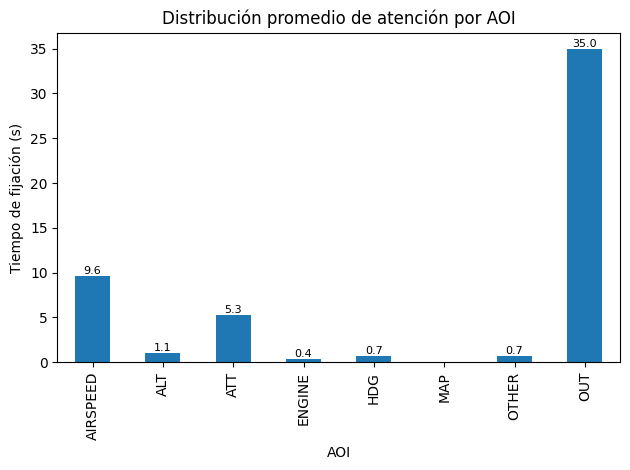

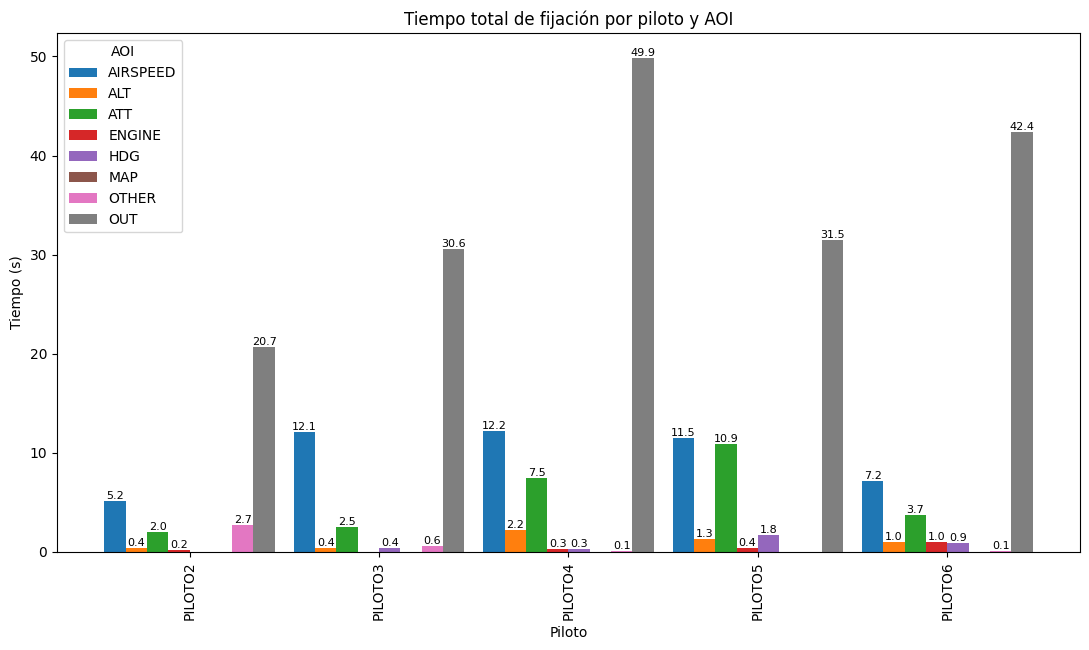

<Figure size 640x480 with 0 Axes>

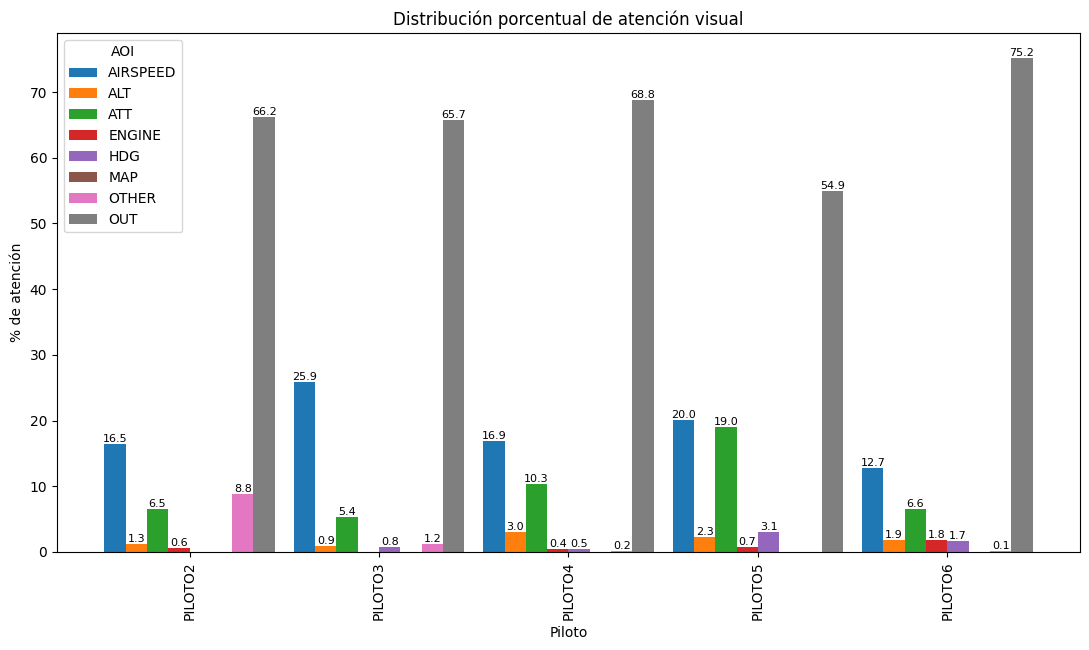

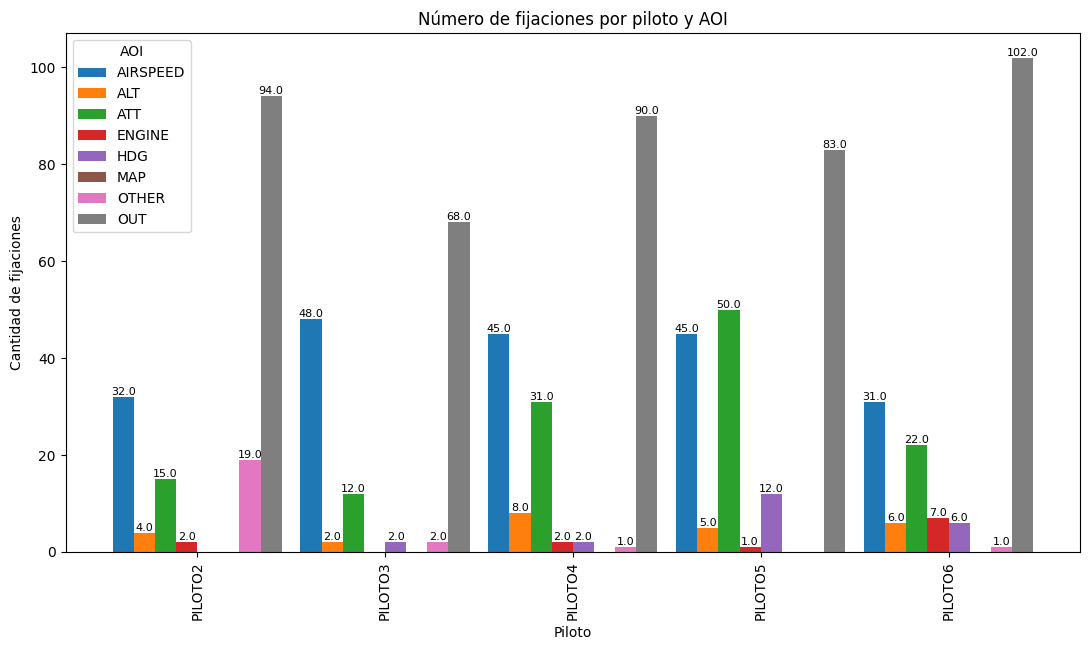

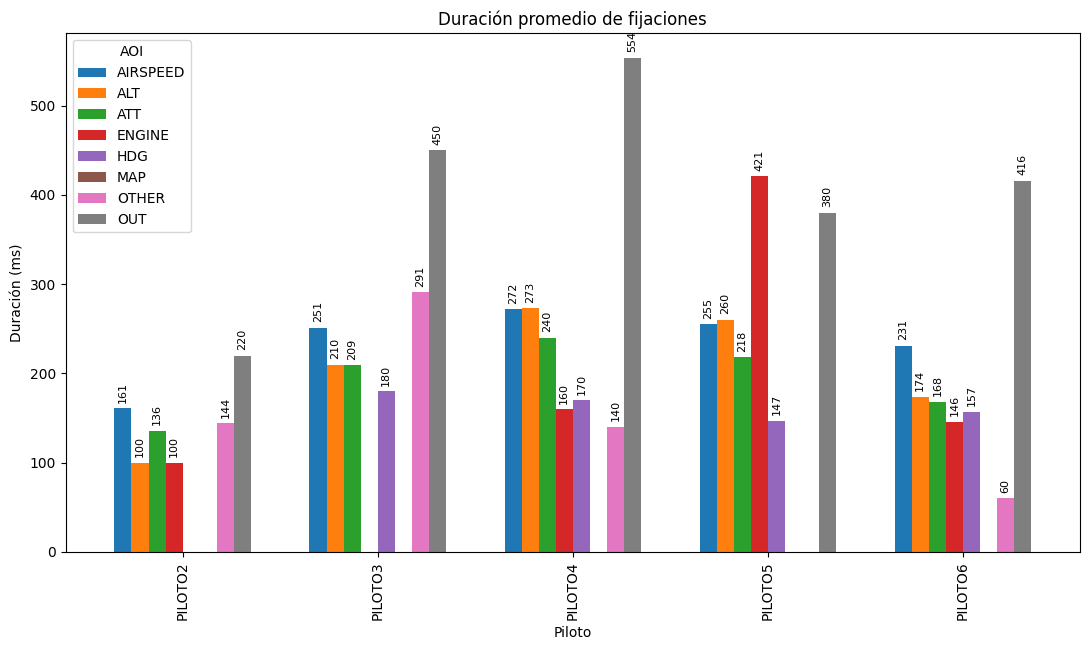

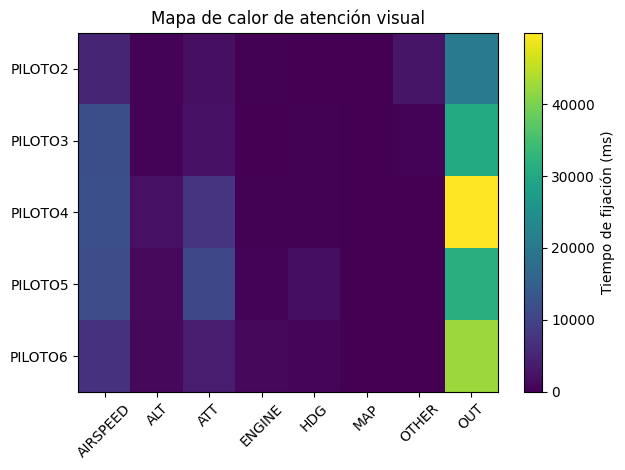

In [11]:
# =========================
# 7. GRÁFICOS
# =========================

# 6.1 Distribución promedio de atención por AOI
fig_1, ax_1 = plt.subplots()
(df.groupby("AOI")["FixTime_ms"].mean() / 1000).plot(kind='bar', ax=ax_1)
ax_1.set_title("Distribución promedio de atención por AOI")
ax_1.set_ylabel("Tiempo de fijación (s)")
ax_1.set_xlabel("AOI")

for p in ax_1.patches:
    height = p.get_height()

    if height > 0:  # evitar poner etiquetas en ceros
        ax_1.annotate(f'{height:.1f}',
                      (p.get_x() + p.get_width() / 2, height),
                      ha='center', va='bottom',
                      fontsize=8)

plt.tight_layout()
plt.show()

# =========================

# 6.2 Comparación por piloto (tiempo total)
fig_2, ax_2 = plt.subplots(figsize=(10*1.1, 6*1.1))
(pivot_time / 1000).plot(kind='bar', ax=ax_2, width=0.9)
ax_2.set_title("Tiempo total de fijación por piloto y AOI")
ax_2.set_ylabel("Tiempo (s)")
ax_2.set_xlabel("Piloto")
ax_2.legend(title="AOI", bbox_to_anchor=(1.1, 1.2))
ax_2.legend(title="AOI", loc="upper left", bbox_to_anchor=(0, 1))

for p in ax_2.patches:
    height = p.get_height()

    if height > 0:  # evitar poner etiquetas en ceros
        ax_2.annotate(f'{height:.1f}',
                      (p.get_x() + p.get_width() / 2, height),
                      ha='center', va='bottom',
                      fontsize=8)

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

# =========================

# 6.3 Distribución porcentual
fig_3, ax_3 = plt.subplots(figsize=(10*1.1, 6*1.1))
pivot_pct.plot(kind='bar', ax=ax_3, width=0.9)
ax_3.set_title("Distribución porcentual de atención visual")
ax_3.set_ylabel("% de atención")
ax_3.set_xlabel("Piloto")
ax_3.legend(title="AOI", bbox_to_anchor=(1.05, 1))
ax_3.legend(title="AOI", loc="upper left", bbox_to_anchor=(0, 1))

for p in ax_3.patches:
    height = p.get_height()

    if height > 0:  # evitar poner etiquetas en ceros
        ax_3.annotate(f'{height:.1f}',
                      (p.get_x() + p.get_width() / 2, height),
                      ha='center', va='bottom',
                      fontsize=8)

plt.tight_layout()
plt.show()

# =========================

# 6.4 Número de fijaciones
fig_4, ax_4 = plt.subplots(figsize=(10*1.1, 6*1.1))
pivot_fix.plot(kind='bar', ax=ax_4, width=0.9)
ax_4.set_title("Número de fijaciones por piloto y AOI")
ax_4.set_ylabel("Cantidad de fijaciones")
ax_4.set_xlabel("Piloto")
ax_4.legend(title="AOI", bbox_to_anchor=(1.05, 1))
ax_4.legend(title="AOI", loc="upper left", bbox_to_anchor=(0, 1))

for p in ax_4.patches:
    height = p.get_height()

    if height > 0:  # evitar poner etiquetas en ceros
        ax_4.annotate(f'{height:.1f}',
                      (p.get_x() + p.get_width() / 2, height),
                      ha='center', va='bottom',
                      fontsize=8)

plt.tight_layout()
plt.show()

# =========================

# 6.5 Duración promedio de fijaciones
fig_5, ax_5 = plt.subplots(figsize=(10*1.1, 6*1.1))
pivot_avg.plot(kind='bar', ax=ax_5, width=0.7)
ax_5.set_title("Duración promedio de fijaciones")
ax_5.set_ylabel("Duración (ms)")
ax_5.set_xlabel("Piloto")
ax_5.legend(title="AOI", bbox_to_anchor=(1.05, 1))
ax_5.legend(title="AOI", loc="upper left", bbox_to_anchor=(0, 1))

for p in ax_5.patches:
    height = p.get_height()

    if height > 0:
        ax_5.annotate(f'{height:.0f}',
                      (p.get_x() + p.get_width() / 2, height),
                      ha='center',
                      va='bottom',
                      fontsize=8,
                      rotation=90,
                      xytext=(0, 4),   #separación vertical
                      textcoords='offset points')

plt.tight_layout()
plt.show()

# =========================

# 6.6 HEATMAP
fig_6, ax_6 = plt.subplots()
im = ax_6.imshow(pivot_time, aspect='auto')
fig_6.colorbar(im, ax=ax_6, label="Tiempo de fijación (ms)")
ax_6.set_xticks(range(len(pivot_time.columns)))
ax_6.set_xticklabels(pivot_time.columns, rotation=45)
ax_6.set_yticks(range(len(pivot_time.index)))
ax_6.set_yticklabels(pivot_time.index)
ax_6.set_title("Mapa de calor de atención visual")
plt.tight_layout()
plt.show()

In [12]:
df = df[df["AOI"] != "MAP"]

In [13]:
# =========================
# 8. RESUMEN ESTADÍSTICO
# =========================

print("\n" + "="*60)
print("RESUMEN ESTADÍSTICO GENERAL DEL EXPERIMENTO")
print("="*60)

# -------------------------
# 8.1 Estadísticos descriptivos
# -------------------------
resumen_general = df.groupby("AOI")[[
    "FixTime_ms",
    "FixAvg_ms",
    "FixCount",
    "Total_duration_of_Visit",
    "Total_duration_of_Glances"
]].describe().round(2)

print("\n[1] Estadísticos descriptivos de variables principales")
for aoi, data in resumen_general.groupby(level=0):
    print(f"\n=== AOI: {aoi} ===")
    print(data.T.to_string())

# -------------------------
# 8.2 Tiempo total por piloto
# -------------------------
tiempo_piloto = df.groupby("Pilot")["FixTime_ms"].sum().sort_values(ascending=False)

print("\n[2] Tiempo total de fijación por piloto (ms)")
print(tiempo_piloto.to_string())

# -------------------------
# 8.3 Distribución promedio por AOI
# -------------------------
tiempo_aoi = df.groupby("AOI")["FixTime_ms"].mean().sort_values(ascending=False)

print("\n[3] Tiempo promedio de fijación por AOI (ms)")
print(tiempo_aoi.to_string())

# -------------------------
# 8.4 Distribución relativa (% atención)
# -------------------------
distribucion_pct = df.pivot_table(
    index="Pilot",
    columns="AOI",
    values="Percentage",
    aggfunc="mean"
).round(2)

print("\n[4] Distribución porcentual de la atención visual por piloto y AOI (%)")
print(distribucion_pct.to_string())


RESUMEN ESTADÍSTICO GENERAL DEL EXPERIMENTO

[1] Estadísticos descriptivos de variables principales

=== AOI: AIRSPEED ===
AOI                              AIRSPEED
FixTime_ms                count      5.00
                          mean    9625.80
                          std     3250.87
                          min     5156.00
                          25%     7173.00
                          50%    11496.00
                          75%    12062.00
                          max    12242.00
FixAvg_ms                 count      5.00
                          mean     234.00
                          std       43.34
                          min      161.00
                          25%      231.00
                          50%      251.00
                          75%      255.00
                          max      272.00
FixCount                  count      5.00
                          mean      40.20
                          std        8.04
                          min       